In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
 
print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
base = os.getcwd()
prefix = "../" if "notebooks" in base else ""
 
nav_df  = pd.read_csv(f"{prefix}data/processed/nav_history_cleaned.csv")
fund_df = pd.read_csv(f"{prefix}data/processed/fund_master_cleaned.csv")
 
nav_df["date"] = pd.to_datetime(nav_df["date"])
nav_df = nav_df.sort_values(["amfi_code","date"])
nav_df["daily_return"] = nav_df.groupby("amfi_code")["nav"].pct_change()
nav_df = nav_df.dropna(subset=["daily_return"])
 
print("✅ Data loaded")
print("Shape:", nav_df.shape)
nav_df.head()

✅ Data loaded
Shape: (45922, 4)


,amfi_code,date,nav,daily_return
1,100016,2022-01-03,503.1674,-0.017467
2,100016,2022-01-04,531.2850,0.055881
3,100016,2022-01-06,474.1732,-0.107497
4,100016,2022-01-07,452.5840,-0.045530
5,100016,2022-01-08,433.0211,-0.043225


In [3]:
def calculate_cagr(df, amfi_code):
    fund = df[df["amfi_code"] == amfi_code].sort_values("date")
    if len(fund) < 2:
        return None
    start_nav = fund.iloc[0]["nav"]
    end_nav   = fund.iloc[-1]["nav"]
    n_days    = (fund.iloc[-1]["date"] - fund.iloc[0]["date"]).days
    if n_days == 0:
        return None
    n_years = n_days / 365
    cagr = ((end_nav / start_nav) ** (1 / n_years) - 1) * 100
    return round(cagr, 2)
 
cagr_list = []
for code in nav_df["amfi_code"].unique():
    cagr = calculate_cagr(nav_df, code)
    name = fund_df[fund_df["amfi_code"] == code]["scheme_name"].values
    if len(name) > 0 and cagr is not None:
        cagr_list.append({
            "amfi_code": code,
            "scheme_name": name[0],
            "cagr_pct": cagr
        })
 
cagr_df = pd.DataFrame(cagr_list).sort_values("cagr_pct", ascending=False).reset_index(drop=True)
os.makedirs(f"{prefix}data/processed", exist_ok=True)
cagr_df.to_csv(f"{prefix}data/processed/cagr_results.csv", index=False)
print("=== CAGR Results ===")
print(cagr_df)
print("✅ CAGR saved")

=== CAGR Results ===
    amfi_code                                        scheme_name  cagr_pct
0      100016          HDFC Top 100 Fund - Regular Plan - Growth       NaN
1      100025       HDFC Short Term Debt Fund - Regular - Growth       NaN
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...       NaN
3      101206      ABSL Frontline Equity Fund - Regular - Growth       NaN
4      101207             ABSL Small Cap Fund - Regular - Growth       NaN
5      101208                ABSL Liquid Fund - Regular - Growth       NaN
6      102885         UTI Nifty 50 Index Fund - Regular - Growth       NaN
7      102886                UTI Mid Cap Fund - Regular - Growth       NaN
8      102887              UTI Flexi Cap Fund - Regular - Growth       NaN
9      118632     Nippon India Large Cap Fund - Regular - Growth       NaN
10     118633      Nippon India Large Cap Fund - Direct - Growth       NaN
11     118634     Nippon India Small Cap Fund - Regular - Growth       NaN
12  

In [4]:
RISK_FREE_DAILY = 6.5 / 100 / 252
 
sharpe_list = []
for code in nav_df["amfi_code"].unique():
    returns = nav_df[nav_df["amfi_code"] == code]["daily_return"]
    if len(returns) < 30 or returns.std() == 0:
        continue
    sharpe = (returns.mean() - RISK_FREE_DAILY) / returns.std() * np.sqrt(252)
    name = fund_df[fund_df["amfi_code"] == code]["scheme_name"].values
    if len(name) > 0:
        sharpe_list.append({
            "amfi_code": code,
            "scheme_name": name[0],
            "sharpe_ratio": round(sharpe, 3)
        })
 
sharpe_df = pd.DataFrame(sharpe_list).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
sharpe_df.to_csv(f"{prefix}data/processed/sharpe_results.csv", index=False)
print("=== Sharpe Ratio Results ===")
print(sharpe_df)
print("✅ Sharpe saved")

=== Sharpe Ratio Results ===
    amfi_code                                        scheme_name  sharpe_ratio
0      149324              DSP Small Cap Fund - Regular - Growth         0.963
1      119598         SBI Small Cap Fund - Regular Plan - Growth         0.855
2      120843             Kotak Flexicap Fund - Regular - Growth         0.846
3      120505           ICICI Pru Midcap Fund - Regular - Growth         0.841
4      148567      Mirae Asset Large Cap Fund - Regular - Growth         0.820
5      149323                 DSP Midcap Fund - Regular - Growth         0.804
6      119094                Axis Midcap Fund - Regular - Growth         0.802
7      148569      Mirae Asset Tax Saver Fund - Regular - Growth         0.767
8      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...         0.765
9      119551          SBI Bluechip Fund - Regular Plan - Growth         0.720
10     118632     Nippon India Large Cap Fund - Regular - Growth         0.659
11     118634     Nippo

In [5]:
vol_list = []
for code in nav_df["amfi_code"].unique():
    returns = nav_df[nav_df["amfi_code"] == code]["daily_return"]
    if len(returns) < 30:
        continue
    vol = returns.std() * np.sqrt(252) * 100
    name = fund_df[fund_df["amfi_code"] == code]["scheme_name"].values
    if len(name) > 0:
        vol_list.append({
            "amfi_code": code,
            "scheme_name": name[0],
            "annual_volatility_pct": round(vol, 2)
        })
 
vol_df = pd.DataFrame(vol_list).sort_values("annual_volatility_pct").reset_index(drop=True)
vol_df.to_csv(f"{prefix}data/processed/volatility_results.csv", index=False)
print("=== Volatility Results ===")
print(vol_df)
print("✅ Volatility saved")
 

=== Volatility Results ===
    amfi_code                                        scheme_name  \
0      101208                ABSL Liquid Fund - Regular - Growth   
1      120844               Kotak Liquid Fund - Regular - Growth   
2      100025       HDFC Short Term Debt Fund - Regular - Growth   
3      120507           ICICI Pru Liquid Fund - Regular - Growth   
4      119120       SBI Magnum Gilt Fund - Regular Plan - Growth   
5      118636  Nippon India Gilt Securities Fund - Regular - ...   
6      119092              Axis Bluechip Fund - Regular - Growth   
7      100016          HDFC Top 100 Fund - Regular Plan - Growth   
8      102885         UTI Nifty 50 Index Fund - Regular - Growth   
9      120842      Kotak Emerging Equity Fund - Regular - Growth   
10     118635                     Nippon India ETF Nifty 50 BeES   
11     119093               Axis Bluechip Fund - Direct - Growth   
12     118633      Nippon India Large Cap Fund - Direct - Growth   
13     149322        

In [6]:
var_list = []
for code in nav_df["amfi_code"].unique():
    returns = nav_df[nav_df["amfi_code"] == code]["daily_return"]
    if len(returns) < 30:
        continue
    var95 = np.percentile(returns, 5) * 100
    name = fund_df[fund_df["amfi_code"] == code]["scheme_name"].values
    if len(name) > 0:
        var_list.append({
            "amfi_code": code,
            "scheme_name": name[0],
            "var_95_pct": round(var95, 3)
        })
 
var_df = pd.DataFrame(var_list).sort_values("var_95_pct").reset_index(drop=True)
var_df.to_csv(f"{prefix}data/processed/var_results.csv", index=False)
print("=== VaR 95% Results ===")
print(var_df)
print("✅ VaR saved")

=== VaR 95% Results ===
    amfi_code                                        scheme_name  var_95_pct
0      119598         SBI Small Cap Fund - Regular Plan - Growth     -12.585
1      119095             Axis Small Cap Fund - Regular - Growth     -10.189
2      119599          SBI Small Cap Fund - Direct Plan - Growth      -9.805
3      149324              DSP Small Cap Fund - Regular - Growth      -9.403
4      148569      Mirae Asset Tax Saver Fund - Regular - Growth      -9.139
5      118634     Nippon India Small Cap Fund - Regular - Growth      -9.087
6      101207             ABSL Small Cap Fund - Regular - Growth      -8.954
7      120843             Kotak Flexicap Fund - Regular - Growth      -7.683
8      101206      ABSL Frontline Equity Fund - Regular - Growth      -7.469
9      120505           ICICI Pru Midcap Fund - Regular - Growth      -7.414
10     120842      Kotak Emerging Equity Fund - Regular - Growth      -7.235
11     119094                Axis Midcap Fund - Regu

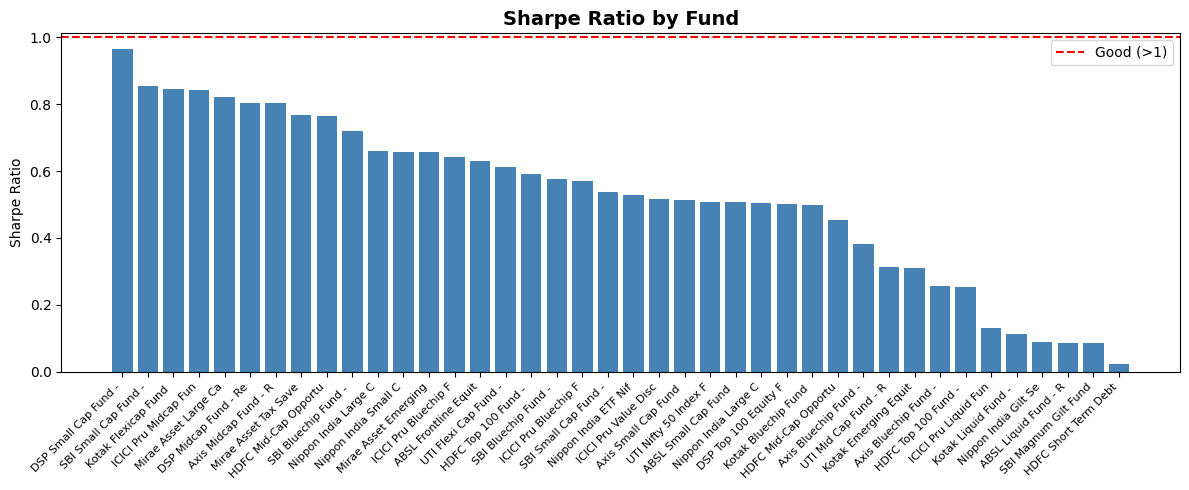

✅ Chart 7 saved


In [7]:
os.makedirs(f"{prefix}reports", exist_ok=True)
 
plt.figure(figsize=(12, 5))
colors = ["green" if x > 1 else "steelblue" if x > 0 else "red"
          for x in sharpe_df["sharpe_ratio"]]
plt.bar(range(len(sharpe_df)), sharpe_df["sharpe_ratio"], color=colors)
plt.xticks(range(len(sharpe_df)),
           [s[:20] for s in sharpe_df["scheme_name"]],
           rotation=45, ha="right", fontsize=8)
plt.title("Sharpe Ratio by Fund", fontsize=14, fontweight="bold")
plt.ylabel("Sharpe Ratio")
plt.axhline(y=1, color="red", linestyle="--", label="Good (>1)")
plt.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(f"{prefix}reports/chart7_sharpe_ratio.png", dpi=150)
plt.show()
print("✅ Chart 7 saved")

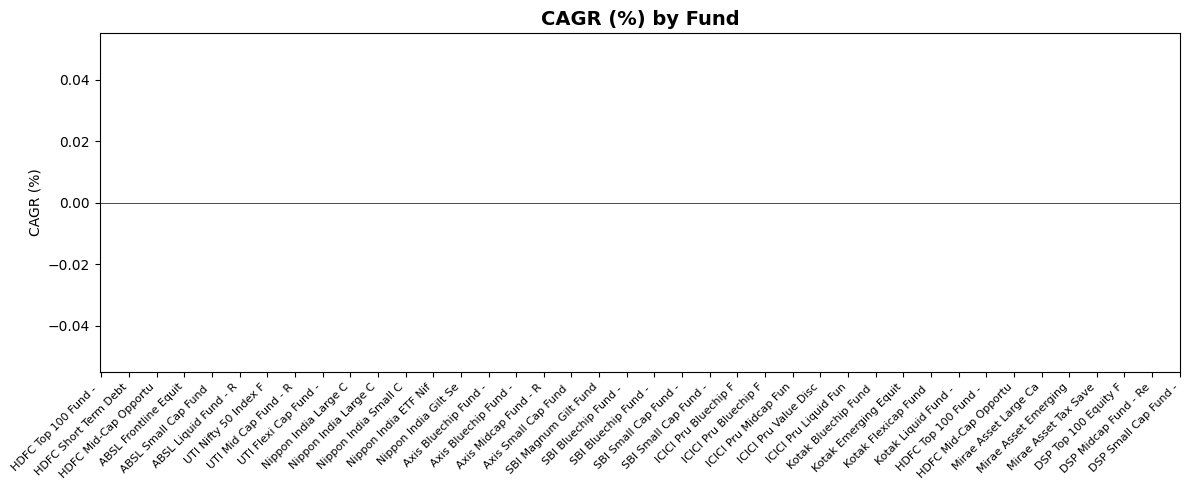

✅ Chart 8 saved


In [8]:
plt.figure(figsize=(12, 5))
colors = ["green" if x > 0 else "red" for x in cagr_df["cagr_pct"]]
plt.bar(range(len(cagr_df)),
        cagr_df["cagr_pct"], color=colors)
plt.xticks(range(len(cagr_df)),
           [s[:20] for s in cagr_df["scheme_name"]],
           rotation=45, ha="right", fontsize=8)
plt.title("CAGR (%) by Fund", fontsize=14, fontweight="bold")
plt.ylabel("CAGR (%)")
plt.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
plt.tight_layout()
plt.savefig(f"{prefix}reports/chart8_cagr.png", dpi=150)
plt.show()
print("✅ Chart 8 saved")

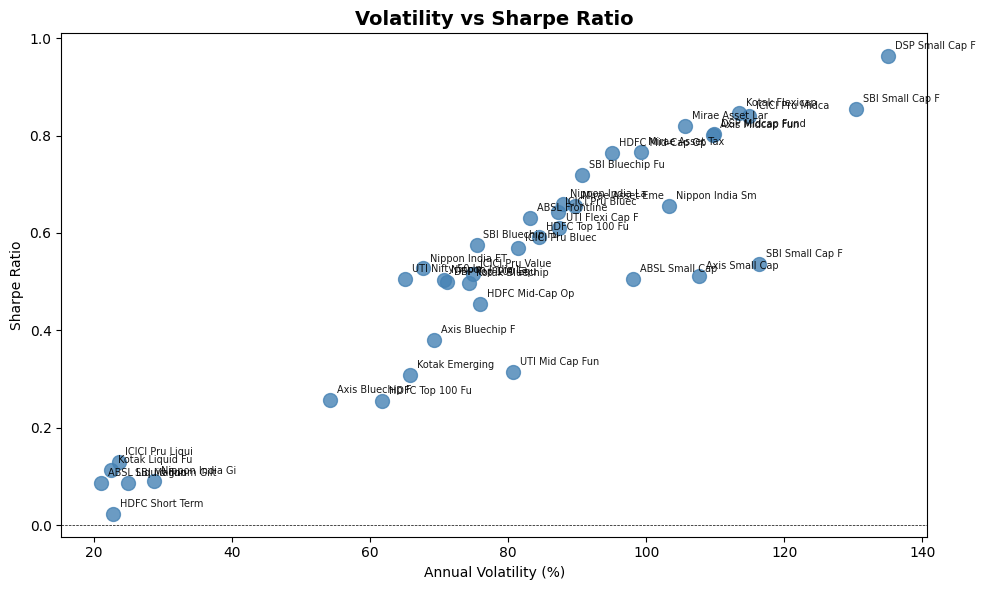

✅ Chart 9 saved


In [9]:
merged = sharpe_df.merge(vol_df, on=["amfi_code","scheme_name"])
 
plt.figure(figsize=(10, 6))
plt.scatter(merged["annual_volatility_pct"],
            merged["sharpe_ratio"],
            color="steelblue", s=100, alpha=0.8)
for _, row in merged.iterrows():
    plt.annotate(str(row["scheme_name"])[:15],
                 (row["annual_volatility_pct"], row["sharpe_ratio"]),
                 fontsize=7, alpha=0.9,
                 xytext=(5, 5), textcoords="offset points")
plt.title("Volatility vs Sharpe Ratio",
          fontsize=14, fontweight="bold")
plt.xlabel("Annual Volatility (%)")
plt.ylabel("Sharpe Ratio")
plt.axhline(y=0, color="black", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.savefig(f"{prefix}reports/chart9_volatility_vs_sharpe.png", dpi=150)
plt.show()
print("✅ Chart 9 saved")

In [10]:
print("""
=== PERFORMANCE METRICS SUMMARY ===
 
Best CAGR Fund          : {} ({:.2f}%)
Best Sharpe Ratio Fund  : {} ({:.3f})
Lowest Volatility Fund  : {} ({:.2f}%)
Highest Risk VaR Fund   : {} ({:.3f}%)
 
Total funds analysed    : {}
""".format(
    cagr_df.iloc[0]["scheme_name"], cagr_df.iloc[0]["cagr_pct"],
    sharpe_df.iloc[0]["scheme_name"], sharpe_df.iloc[0]["sharpe_ratio"],
    vol_df.iloc[0]["scheme_name"], vol_df.iloc[0]["annual_volatility_pct"],
    var_df.iloc[0]["scheme_name"], var_df.iloc[0]["var_95_pct"],
    len(cagr_df)
))
print("✅ Day 4 Performance Analytics Complete!")


=== PERFORMANCE METRICS SUMMARY ===

Best CAGR Fund          : HDFC Top 100 Fund - Regular Plan - Growth (nan%)
Best Sharpe Ratio Fund  : DSP Small Cap Fund - Regular - Growth (0.963)
Lowest Volatility Fund  : ABSL Liquid Fund - Regular - Growth (21.00%)
Highest Risk VaR Fund   : SBI Small Cap Fund - Regular Plan - Growth (-12.585%)

Total funds analysed    : 40

✅ Day 4 Performance Analytics Complete!
